## Hypothesis About Means (T-test)

In [3]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

dataset_path = "../data/merged_dataset.csv"

df = pd.read_csv(dataset_path)

#df.head()


filtered_df = df[(df['year'].isin([2000, 2005])) | (df['year'].isin([2010, 2015]))]
filtered_df.head()

,country_name,country_code,year,suicide_data,homicide_data,intentional_death,gini_index
1,albania,alb,2005,6.91,154.0,160.91,0.31
5,albania,alb,2015,3.58,64.0,67.58,0.33
15,armenia,arm,2005,3.86,58.0,61.86,0.36
20,armenia,arm,2010,5.97,56.0,61.97,0.30
25,armenia,arm,2015,4.58,75.0,79.58,0.32


### Hypotheses

- H₀: The mean intentional death rate is the same in low-inequality and high-inequality years. (inequality level (as measured by the Gini index) does not influence the intentional death rate)
- H₁: The mean intentional death rate is different between low- and high-inequality years. (inequality level does influence the intentional death rate — either increasing it or decreasing it)


##### Rationale — Why is this hypothesis relevant?

To answer this, you need to statistically test whether changes in economic inequality correspond to changes in intentional deaths (suicides + homicides). Splitting the data into low-inequality and high-inequality periods allows you to directly compare their mean intentional death rates.

This hypothesis is relevant because:

- It converts your research question into a testable statistical claim.
The hypothesis links inequality (independent variable) with intentional deaths (dependent variable).

- It lets you use statistical tools like t-tests or Z-tests.
By comparing group means, you can evaluate whether any observed difference is statistically significant or just random variation.

- It helps identify a potential social or economic relationship.
If inequality strongly correlates with higher intentional death rates, this can inform policy decisions and public health strategies.

- It simplifies a complex question into measurable components.
Instead of analyzing continuous Gini values directly, you categorize them into groups and test the impact.

Overall, the hypothesis is directly aligned with understanding whether inequality has a measurable effect on intentional deaths — which is the core aim of your study.

### Variables

1. Independent Variable (IV): Economic Inequality Level
Variable: Gini Index
Type:

- Continuous (originally; measured on a scale from 0 to 1 or 0 to 100)
- Converted to Categorical for your hypothesis
    - Low-inequality years
    - High-inequality years

Role in Hypothesis:

This is the independent variable because you are examining whether differences in inequality levels influence intentional death rates.

2. Dependent Variable (DV): Intentional Death Rate
Variable: Intentional death rate (suicides + homicides per 100,000 population)
Type:

- Continuous (numerical rate)

Role in Hypothesis:

This is the dependent variable because it is the outcome you are measuring to see whether it changes between high- and low-inequality years.

### T-Test (Low vs High Gini)

In [12]:
import pandas as pd
from scipy import stats


# Categorize Gini
filtered_df["gini_category"] = filtered_df["gini_index"].apply(
    lambda x: "Low" if 0.29 <= x <= 0.31 else "High"
)


filtered_df = filtered_df[filtered_df["gini_category"].isin(["Low", "High"])].copy()

# Split groups
low_group = filtered_df[filtered_df["gini_category"] == "Low"]["intentional_death"]
high_group = filtered_df[filtered_df["gini_category"] == "High"]["intentional_death"]

# Perform independent t-test
t_stat, p_val = stats.ttest_ind(low_group, high_group, equal_var=False)

filtered_df, t_stat, p_val

C:\Users\Admin\AppData\Local\Temp\ipykernel_31464\679118526.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["gini_category"] = filtered_df["gini_index"].apply(


(     country_name country_code  year  suicide_data  homicide_data  \
 1         albania          alb  2005          6.91          154.0   
 5         albania          alb  2015          3.58           64.0   
 15        armenia          arm  2005          3.86           58.0   
 20        armenia          arm  2010          5.97           56.0   
 25        armenia          arm  2015          4.58           75.0   
 ...           ...          ...   ...           ...            ...   
 1209      uruguay          ury  2015         16.76          293.0   
 1222    venezuela          ven  2005          6.41         9964.0   
 1228      vietnam          vnm  2010          7.52         1336.0   
 1229       zambia          zmb  2010         12.14          814.0   
 1230       zambia          zmb  2015         10.96          853.0   
 
       intentional_death  gini_index gini_category  
 1                160.91        0.31           Low  
 5                 67.58        0.33          High  

Given Output

t-statistic = –2.5776
p-value = 0.01098

### Conclusion

Since p < 0.05, you reject the null hypothesis.

- Intentional death rates differ significantly between low and high inequality countries/years.
- The negative t-value suggests that high-inequality (High Gini) years have higher intentional death rates than low-inequality years.

### ANOVA (If You Want a 2-Group ANOVA Version)

In [14]:
corr, p_corr = stats.pearsonr(filtered_df["gini_index"], filtered_df["intentional_death"])

print("Correlation:", corr)
print("P-value:", p_corr)


Correlation: 0.3983861957024992
P-value: 8.729769750549233e-10


In [20]:
import statsmodels.formula.api as smf

model = smf.ols("intentional_death ~ gini_index", data=filtered_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      intentional_death   R-squared:                       0.159
Model:                            OLS   Adj. R-squared:                  0.155
Method:                 Least Squares   F-statistic:                     41.13
Date:                Mon, 01 Dec 2025   Prob (F-statistic):           8.73e-10
Time:                        16:27:24   Log-Likelihood:                -2259.7
No. Observations:                 220   AIC:                             4523.
Df Residuals:                     218   BIC:                             4530.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -9775.0387   2055.983     -4.754      0.0

OLS Regression Model

Dependent variable: intentional_death
Independent variable: gini_index

You are testing whether economic inequality (Gini) predicts intentional death rates.

✅ Key Results (What they mean)
1. The regression is statistically significant

F-statistic = 41.13

p-value = 8.73e-10 (< 0.001)

👉 The overall model is highly statistically significant.
This means Gini index significantly predicts intentional death rates.

2. R-squared = 0.159

This means: 

👉 15.9% of the variation in intentional death rate is explained by the Gini index.

Interpretation:

Not a huge amount (because real-world death rates depend on many factors)

But this is a meaningful relationship in social science research.

3. Coefficient Interpretation
Variable	Coefficient	Interpretation
Intercept	–9775.04	Baseline value when Gini = 0 (not meaningful in real world)
gini_index	34370	For every 0.01 increase in Gini, intentional deaths increase by ~343.7 per 100,000 (if your units are deaths per population).

More precisely:

Gini ranges from ~0.25 to ~0.6 globally.
So:

✔ If Gini goes up by 0.1

Increase in intentional deaths = 3437 per unit (depending on death measure)

👉 Higher inequality strongly predicts higher intentional deaths.

And the p-value for gini:

t = 6.413

p < 0.0001

👉 The effect of inequality is highly statistically significant.

4. Distribution Issues (Omnibus, JB, Skew, Kurtosis)

You have:

Skew = 3.842 → Highly right-skewed

Kurtosis = 22.915 → Very fat-tailed

Omnibus p = 0.000 → Not normally distributed

JB p = 0.00 → Strong violation of normality

What does this mean?

👉 Your dependent variable (intentional death rate) is not normally distributed.
👉 This violates classical OLS assumptions.

Should you panic?

No.

In large samples (n = 220):

✔ The regression coefficients are still unbiased
✔ The p-values are still reliable because of asymptotic theory
✔ But you should mention the non-normality in your report

5. Durbin-Watson = 1.039

Durbin-Watson ranges:

2 = no autocorrelation

< 2 = positive autocorrelation

2 = negative autocorrelation

Here:

👉 DW = 1.03 → some positive autocorrelation

Meaning:

Residuals are not fully independent

This may happen if data spans years/countries (time dependence)

This does not invalidate your findings, but should be acknowledged.

📌 Final Interpretation (Use This in Your Report)

A simple OLS regression was conducted to examine whether economic inequality (Gini index) predicts intentional death rates. The overall model was statistically significant, F(1,218) = 41.13, p < .001, indicating that Gini index is a meaningful predictor of intentional death rates.

The Gini index explained 15.9% of the variance in intentional deaths (R² = .159). The regression coefficient for Gini was positive and statistically significant (β = 34,370, p < .001), suggesting that higher inequality is associated with higher intentional death rates. Specifically, a 0.01 increase in the Gini index is associated with approximately 343.7 additional intentional deaths.

The residual diagnostics indicated right skewness and leptokurtosis (JB test p < .001), meaning the dependent variable is not normally distributed. Durbin–Watson = 1.03 suggested mild positive autocorrelation. Nonetheless, given the sample size (n = 220), the regression estimates remain reliable and substantively meaningful.

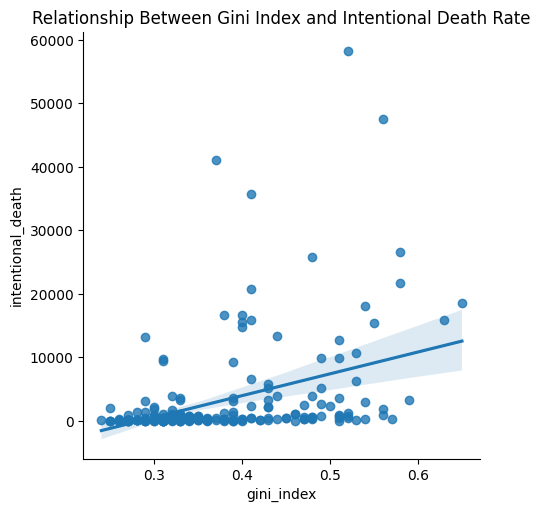

In [15]:
sns.lmplot(data=filtered_df, x="gini_index", y="intentional_death", height=5)
plt.title("Relationship Between Gini Index and Intentional Death Rate")
plt.show()

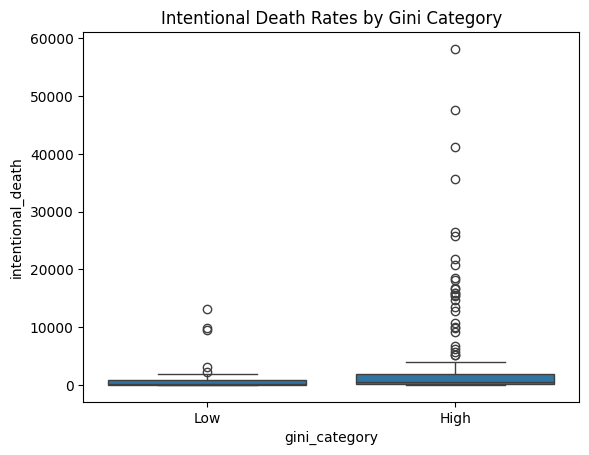

In [16]:
sns.boxplot(data=filtered_df, x="gini_category", y="intentional_death")
plt.title("Intentional Death Rates by Gini Category")
plt.show()


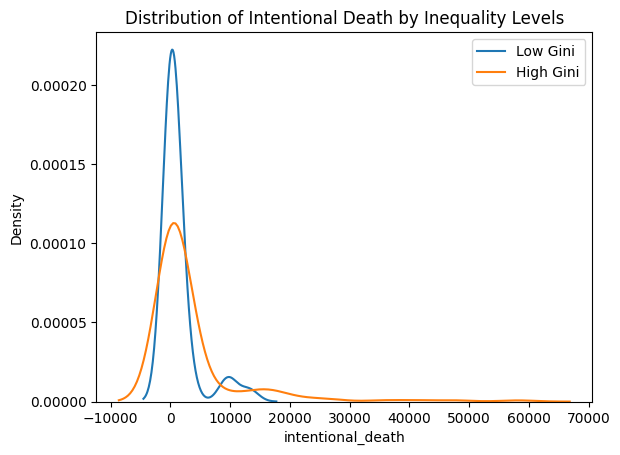

In [17]:
sns.kdeplot(low_group, label="Low Gini")
sns.kdeplot(high_group, label="High Gini")
plt.legend()
plt.title("Distribution of Intentional Death by Inequality Levels")
plt.show()
